In [1]:
%matplotlib inline
import numpy as np
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))
sys.path.append("/home/castrojo/Desktop/MPSD/i-pi")               
from ipitools import utils_free_energy_tutorial as utils
from ipitools.io import read_ipi_output, read_ipi_xyz
from ipi.utils.units import unit_to_user, unit_to_internal, Constants
from scipy.integrate import quad

<p/>
<p style="font-size:48px; font-weight: bolder; text-align: center"> Free Energy Calulations with i-PI </p>
<p style="font-size:18px; text-align: center"><i> authored by:  Hannah Bertschi, Jorge Castro, George Trenins </i></p>
<p style="font-size:18px; text-align: center"><i> adapted from <a href="https://github.com/i-pi/piqm2023-tutorial" target="_blank">tutorials for the PIQM-2023 Advanced School</a></i></p>

<figure style="text-align: center;">
    <img src="figures/intro1.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro2.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro3.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro4.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro5.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro6.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro7.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/intro8.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

# Theoretical background 


## Free Energy Differences

Consider thermodynamic states A and B, characterized Hamiltonians $H_A(\mathbf{p}, \mathbf{q})$ and $H_B(\mathbf{p}, \mathbf{q})$ ($\mathbf{q}$ and $\mathbf{p}$ system’s coordinates and momenta). 

The free energy is given by: 

$$
\Delta F_{AB} = -k_B T \ln \left( \frac{Z_B}{Z_A} \right),
$$

where the partition function for state $X$ is:

$$
Z_X = \int \mathrm{d}\mathbf{p} \, \mathrm{d}\mathbf{q} \; e^{-H_X(\mathbf{p}, \mathbf{q}) / k_B T}
$$ 

## Thermodynamic Integration
 
Thermodynamic Integration (TI) introduces a continuous coupling parameter $\lambda\in[0,1]$ that interpolates smoothly between the two end states.

We define a family of interpolated Hamiltonians,

$$
H_\lambda(\mathbf{p}, \mathbf{q}) \quad \text{such that} \quad
\begin{cases}
H_0 = H_A \\
H_1 = H_B
\end{cases}
$$

The dependence of the Hamiltonian on the coupling parameter $\lambda$ is problem-specific.

Consider systems that only differ in their **potential energy** and choose a linear interpolation as our transformation:


$$
H_\lambda(\mathbf{p}, \mathbf{q}) = (1 - \lambda ) H_A(\mathbf{p}, \mathbf{q}) + \lambda H_B(\mathbf{p}, \mathbf{q}) \\ = \sum_{\alpha}\frac{\lvert\mathbf{p}_{\alpha} \rvert^2}{2 m_{\alpha}} + (1 - \lambda ) U_A( \mathbf{q}) + \lambda U_B( \mathbf{q}) 
$$

Given the free energy $F_{\lambda}$ corresponding to the Hamiltonian $H_{\lambda}$, we may write

$$
\Delta F_{AB} = F_{1} - F_{0} = \int_0^1 \frac{\mathrm{d} F}{\mathrm{d} \lambda} \, \mathrm{d} \lambda
$$


Finally, the free energy difference is computed from

$$
\Delta F_{AB} = \int_{0}^{1} \left\langle U_B(\mathbf{q}) - U_A(\mathbf{q}) \right\rangle_{\lambda} \mathrm{d}\lambda 
$$

by numerical quadrature over $\lambda$ using, e.g., the trapezoidal rule

In practice:

1. **Discretize the $\lambda$-interval** into a set of points $\{\lambda_k\}$ (e.g., 0.0, 0.1, ..., 1.0).  
2. **Run MD or MC simulations** at each $\lambda_k$ to estimate the ensemble average $\left\langle \partial U/\partial \lambda \right\rangle_{\lambda_k}$.  
3. **Numerically integrate** these averages. 

# Free-energy calculation

<figure style="text-align: center;">
    <img src="figures/TOC1.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>


<figure style="text-align: center;">
    <img src="figures/TOC2.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>


<figure style="text-align: center;">
    <img src="figures/TOC3.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/TOC4.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/TOC5.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

<figure style="text-align: center;">
    <img src="figures/TOC_free_energy.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>


<div style="display: flex; align-items: center; justify-content: space-between;">

<div style="flex: 1; padding-right: 20px;">

<h2>Model potential</h2>

We simulate a single hydrogen atom moving in a <strong>composite potential</strong>:

<ul>
  <li><strong>Morse potential</strong> along the z direction: Anharmonic bond with the surface</li>
  <li><strong>Harmonic potential</strong> in x and y directions: Preference for a particular adsorption site</li>
</ul>

<p style="font-size: 120%; text-align: center;">
$$
U(\mathbf{q}) =
D_e \left(1 - \mathrm{e}^{-\alpha\,(z - z_0)} \right)^2
+ \dfrac{1}{2}k(x^2 + y^2)
$$
</p>

</div>

<div style="flex: 1; text-align: center;">
  <img src="figures/h_metal_anim.gif" style="max-width: 100%; height: 300px;">
</div>

</div>



**Parameters**
- Mass $m=1837.4$ $m_{e}$
- Dissociation energy $ D_e = 200 $ meV 
- Bond lenght $ z_0 = 1.11 $ Å   
- Bond stiffness $ \alpha = 1.610 $ Å$^{-1}$, imply harmonic frequency: $ \omega_e = \alpha\sqrt{\frac{2D_e}{m}} \approx 263 \;\mathrm{cm}^{-1},$
 
- Harmonic spring constant $ k $ chosen to match the harmonic frequency $ \omega \approx 520 \,\mathrm{cm}^{-1} $

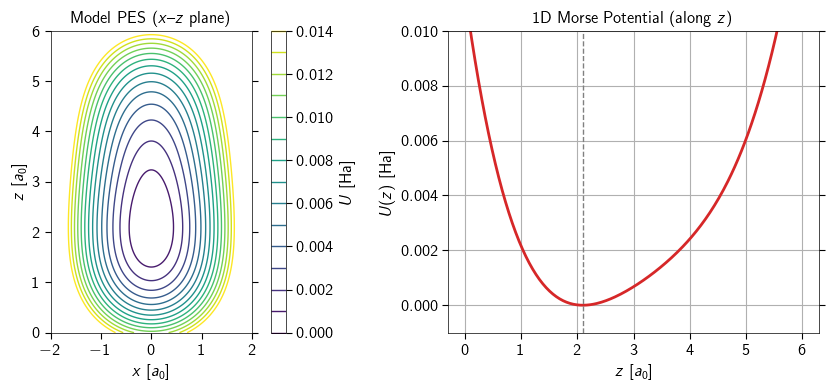

In [2]:
De    = 0.2      # eV
a    = 0.75    # angstrom^(-1)
z0   = 1.11    # angstrom
k    = 1.0     # eV / angstrom^2

# Call the plotting function
fig = utils.plot_pes_morse(D=De, a=a, z0=z0, k=k);

## Harmonic approximation


- **Optimize** the geometry to find the local minimum of the potential energy surface.

- **Compute** the Hessian matrix (second derivatives of the potential):
  
  $$
  H_{ij} = \left. \frac{\partial^2 U}{\partial q_i \partial q_j} \right\rvert_{\mathbf{q} = \mathbf{q}_0}
  $$

- **Diagonalize** the Hessian to obtain the harmonic vibrational frequencies of the system.


For a system with vibrational frequencies $ \{ \omega_n \} $

#### Classical harmonic vibrational free energy:

$$
F_{\text{ch}} = \frac{1}{\beta} \sum_n \ln\left( \beta \hbar \omega_n \right)
$$

#### Quantum harmonic vibrational free energy:


$$
F_{\text{qh}} = \sum_n \left[ \frac{\hbar \omega_n}{2} + \frac{1}{\beta} \ln\left( 1 - e^{-\beta \hbar \omega_n} \right) \right]
$$


### Geometry Optimization

#### Input files

```bash
cd geometry_optimization
```

Open the `input.xml` file:

```xml
<motion mode='minimize'>
  <optimizer mode='bfgs'>
  </optimizer>
</motion>
```
At every step instead we will simply move towards a local minimum of the PES. 

Here we use the robust BFGS method. 

#### Running the calculation
Inside the directory `geometry_optimization` run:

```bash
./run_geometry_opt.sh
```

It launches i-PI in the background and optimizes the geometry specified in `init.xyz` 

```bash
i-pi input.xml > log.i-pi &
i-pi-py_driver -u -a geop -m MorseHarmonic -o 0.2,0.75,1.11,1.0 &> log.driver &
```

The values passed via the `-o`  flag: $D_e$, $\alpha$, $z_0$, and $k$, respectively.


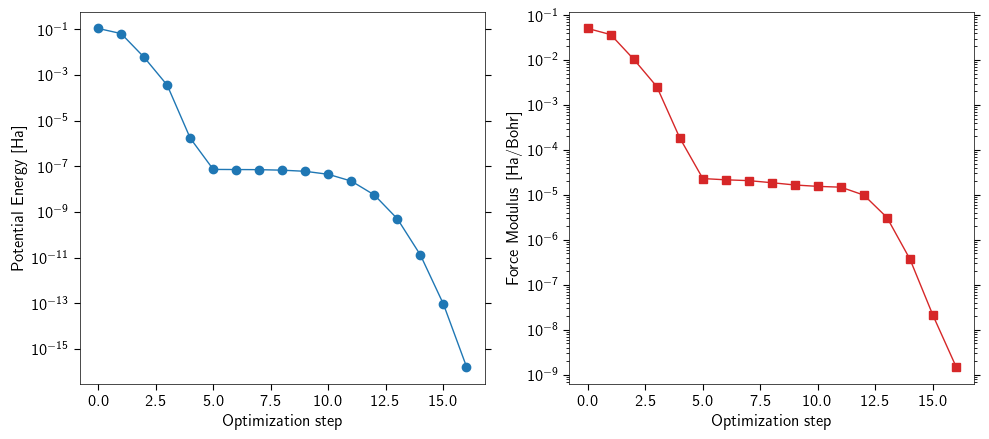

In [3]:
# Is your geometry optimization converged?
basepath = Path('outputs')   # Change to Path('outputs') to load precomputed results
filepath = basepath.joinpath('geometry_optimization', 'simulation.out')
utils.plot_geometry_opt(filepath)

### Hessian Matrix Computation

Move to the `harmonic_approximation` directory

Open the `input.xml` file and locate the following section:

```xml
<motion mode='vibrations'>
  <vibrations mode='fd'>
    <pos_shift> 0.001 </pos_shift>
    <prefix> phonons </prefix>
  </vibrations>
</motion>
```


 - Initialization: Create a symbolic link to the optimized geometry:

```bash
ln -s ../geometry_optimization/RESTART geop-RESTART
```

- Execute `./run_hessian.sh` to launch i-PI and compute the Hessian matrix using central finite-differences

```bash
i-pi input.xml > log.i-pi &
i-pi-py_driver -u -a vib -m MorseHarmonic -o 0.2,3.042,1.111,17.5 &
```

The computed **Hessian** is written to `simulation.phonons.hess`.

The squared normal-mode frequencies are saved to `simulation.phonons.eigval`.

You can now use this files to:
- Obtain **normal mode frequencies**,
- Reconstruct the **harmonic approximation** to the potential energy surface (PES).

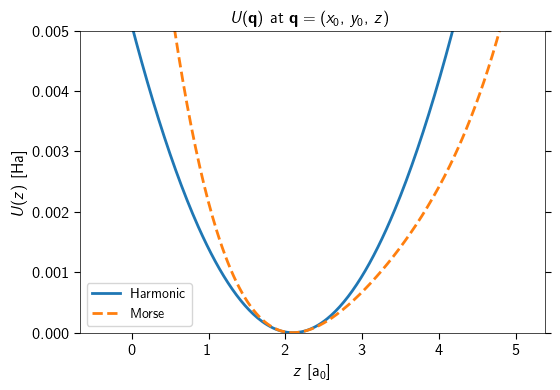

In [4]:
# How do the Morse PES and the harmonic approximation compare?
rootdir = Path(".").joinpath("outputs/harmonic_approximation")
hess = np.loadtxt(rootdir.joinpath("simulation.phonons.hess"))
q0 = unit_to_internal("length", "angstrom",  np.array([0,0,z0]))  # Convert to atomic units
V0 = np.loadtxt(rootdir.joinpath("simulation.out"), usecols=1).item()
utils.compare_pes_1d_z(hess, q0, V0, D=De, a=a, k=k, span_z=(-2.5, 3.0))

### Harmonic free energies

The harmonic calculation also  gives us the frequency modes from the dynamical matrix **K**

In [5]:
# print the harmonic frequencies
rootdir = Path(".").joinpath("outputs/harmonic_approximation")
# The eigval file contains the eigenvalues of the Hessian matrix, i.e., the squares of the frequencies
W2s = np.sort(np.loadtxt(rootdir.joinpath('simulation.phonons.eigval')))[::-1] # sort in decreasing order
Ws = np.sqrt(W2s)
print ('###  Harmonic Frequencies: ###\n')
# The frequencies are in atomic units, we convert to cm^-1
for l,w in zip('xyz', Ws):
    print(f"ω({l}) = {unit_to_user('frequency', 'inversecm', w):7.2f} cm^-1")

###  Harmonic Frequencies: ###

ω(x) =  519.41 cm^-1
ω(y) =  519.41 cm^-1
ω(z) =  246.38 cm^-1


In [6]:
def betaTemp(T):
    """
    Convert from temperature in Kelvin to 1/(kB*T) in atomic units
    """
    T = unit_to_internal("temperature", "kelvin", T)
    beta = 1 / (Constants.kb * T)
    return beta

In [7]:
def classical_harmonic_free_energy(Ws, T):
    """
    Receives a list of frequencies in atomic units and the temperature in Kelvin. 
    Returns the system's classical harmonic free energy.
    """
    beta = betaTemp(T)
    ans = np.log(beta * Constants.hbar * np.asarray(Ws)).sum()
    return ans / beta

In [8]:
def quantum_harmonic_free_energy(Ws, T):
    """
    Receives a list of frequencies in atomic units and the temperature in Kelvin. 
    Returns the system's quantum harmonic free energy.
    """
    beta = betaTemp(T)
    Ws = np.asarray(Ws)
    # zero-point energies
    zpe = Constants.hbar * Ws / 2
    # thermal excitations
    therm = np.log(1 - np.exp(-beta*Constants.hbar*Ws)) / beta
    return (zpe + therm).sum()

In [9]:
# Lets compute the quantum and classical harmonic free energies using the functions defined above
T = 300 # Kelvin
print("Classical harmonic free energy:")
F_ch = classical_harmonic_free_energy(Ws[-1], T)
utils.print_energy(F_ch)
print("Quantum harmonic free energy:")
F_qh = quantum_harmonic_free_energy(Ws[-1], T)
utils.print_energy(F_qh)

Classical harmonic free energy:
   0.159 [mHa]
   4.31 [meV]
   0.416 [kJ/mol]

Quantum harmonic free energy:
   0.213 [mHa]
   5.80 [meV]
   0.560 [kJ/mol]



### Breakdown of the Harmonic Approximation at High Temperature

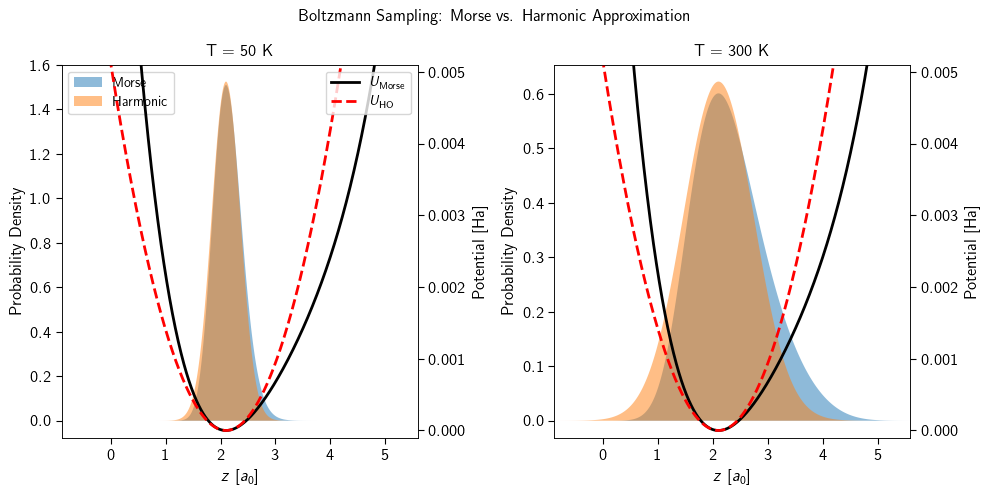

In [10]:
T1 = 50
T2 = 300
utils.plot_boltzmann_distribution_morse_vs_harmonic(T1,T2, span_z=(-3.0, 3.5), D=De, a=a, z0=z0, k=k)


## Classical anharmonic free energies

Define $ \lambda $ to interpolate between $U_{\text{h}}$ and $U_{\text{a}}$:

- $ \lambda = 0 $: Full **harmonic** potential
- $\lambda = 1 $: Full **anharmonic** reference

The anharmonic free energy is then computed as:

$$
F_{\text{ca}} = F_{\text{ch}} + \int_0^1 \left\langle U_{\text{a}} - U_{\text{h}} \right\rangle_\lambda \, d\lambda
$$

$\langle \cdots \rangle_{\lambda}$ denote the thermal average for $\lambda U_{\text{a}}(\mathbf{q}) + (1-\lambda) U_{\text{h}}(\mathbf{q})$. 

Enter the directory

```bash
cd classical_ti
```

Prepare the required input files:

```bash
# link the hessian matrix
ln -s ../harmonic_approximation/simulation.phonons.hess hessian.data 
# store the equilibrium configuration
awk '{print $2, $3, $4}' ../geometry_optimization/simulation.pos_0.xyz | tail -1 > ref.data
# print the equilibrium energy
awk '{print $2}' ../harmonic_approximation/simulation.out | tail -1
#`RESTART` file from the geometry optimization, used to initialize MD
ln -s ../geometry_optimization/RESTART geop-RESTART

```

Open `input.xml`, and modify the following lines to define the mixed potential for thermodynamic integration:

```xml
<!-- Harmonic PES -->
<ffdebye name='harmonic'>
    <hessian shape='(3,3)' mode='file'> ... </hessian>
    <x_reference mode='file'> ... </x_reference>          
    <v_reference> ... </v_reference>                      
</ffdebye>
```

```xml
<!-- Harmonic PES -->
<ffdebye name='harmonic'>
    <hessian shape='(3,3)' mode='file'> hessian.data </hessian>
    <x_reference mode='file'> ref.data </x_reference>           
    <v_reference> 0.0 </v_reference>                           
</ffdebye>
```

```xml
<!-- Anharmonic PES -->
<ffsocket name='anharmonic' mode='unix'>
    <address> f0 </address>
    <latency> 1e-3 </latency>
</ffsocket>
```

Execute`./prepare_directories.sh`:  

It will create a set of directories based on:

$$
\lambda \in \{ 0.0, 0.2, 0.4, 0.6, 0.8, 1.0 \}
$$

Then:

- Compute the input files from the parent directory into  $\lambda$ subfolders
- Specify the linear combination of harmonic and anharmonic forces in each `input.xml`:

```xml
<forces>
   <force forcefield='harmonic' weight='...'> </force>
   <force forcefield='anharmonic' weight='...'> </force> 
</forces>
```

#### Running the TI Simulations

To launch all simulations at once, simply run:

```bash
./run_classical_ti.sh
```
Launch all i-PI instances:

```bash
for x in ?.?/; do cd ${x}; i-pi input.xml > log.i-pi & cd ..; done
```

Launch corresponding drivers with socket IDs:

```bash
for x in {0..10..2}; do i-pi-py_driver -u -a f${x} -m MorseHarmonic -o 0.2,0.75,1.11,1.0 & done
```

#### Analyzing the Free Energy Difference

Get the potential energy components from each `pots` file and numerically integrate:

$$
\Delta F = \int_0^1 \left\langle U_{\text{a}} - {U}_{\text{h}} \right\rangle_\lambda \, d\lambda
$$

The integral gives the **anharmonic correction** to the classical free energy. 


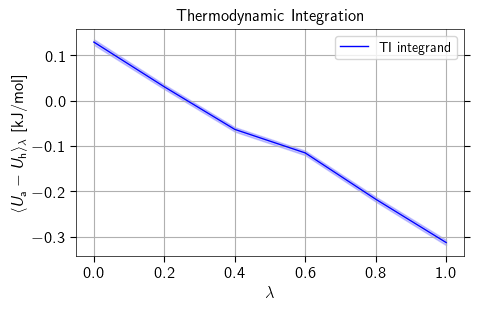

In [11]:
l_list = np.arange(0,11,2)/10
dir_list = [f"{l:.1f}" for l in l_list]
base_path = Path("outputs").joinpath('classical_ti') # Change to Path('outputs') to load precomputed results
filename = 'simulation.pots'
du_list, duerr_list = utils.TI_integrand(dir_list, base_path, filename, skip=100)


In [12]:
# Integrate the energy difference using trapezoidal rule
dF_ch2ca = np.trapz(x=l_list, y=du_list)
# The corresponding error can be computed as
dF_ch2ca_err = np.sqrt(np.trapz(x=l_list, y=duerr_list**2))
# Compute the classical anharmonic free energy by adding the free energy difference to the harmonic free energy
T = 300.0 # Kelvin
F_ch = classical_harmonic_free_energy(Ws[-1], T)
print("Classical harmonic free energy:")
utils.print_energy(F_ch)
print("Anharmonic correction:")
utils.print_energy(dF_ch2ca, error=dF_ch2ca_err)
print("Classical free energy:")
F_ca = F_ch + dF_ch2ca
utils.print_energy(F_ca, error=dF_ch2ca_err)

Classical harmonic free energy:
   0.159 [mHa]
   4.31 [meV]
   0.416 [kJ/mol]

Anharmonic correction:
   -0.035 ± 0.002 [mHa]
   -0.95 ± 0.06 [meV]
   -0.092 ± 0.005 [kJ/mol]

Classical free energy:
   0.124 ± 0.002 [mHa]
   3.36 ± 0.06 [meV]
   0.325 ± 0.005 [kJ/mol]



## Quantum anharmonic free energies

###  Mass Thermodynamic Integration

Mass thermodynamic integration (MTI) allows us to interpolate smoothly between the classical and quantum regimes **without relying on any harmonic approximation**.

We introduce a mass-scaling parameter
$
g = \sqrt{\frac{m_0}{\mu}}
$

where

- $m_0$ is the physical mass of the system, and  
- $\mu$ is the fictitious mass used in each TI quadrature point


The free-energy difference between the classical limit ($g \to 0$) and the quantum system ($g = 1$) is given by
$$
\Delta F^{c \to q} = 2 \int_0^1 \frac{\langle K(g) \rangle - \langle K \rangle^c}{g} \, dg
$$
where
- $\langle K(g) \rangle$ is the quantum kinetic energy (centroid-virial estimator) at mass $\mu = m_0/g^2$
- $\langle K \rangle^c = \tfrac{f}{2}k_B T$ is the classical kinetic energy for a system with $f$ d.o.f

<figure style="text-align: center;">
    <img src="figures/free_energy_plot.png" alt="Free-energy increments from equilibrium to anharmonic quantum" style="width:400px;">
</figure>

### Input files

Navigate to the `mass_ti` directory and open `input.xml`. 

- As we change $g$, the mass is modified:
```xml
    <masses mode="manual"> [ @MASS ] </masses> 
```
- Scaling the mass by $g^{-2}$ affects the timescale on which our system moves, scaling it by $g^{-1}$.  
  For unscaled masses we set $\Delta t = 1.0~\mathrm{fs}$
```xml
    <timestep units='femtosecond'> @DT </timestep> 
```

 - The [PILE-L](https://docs.ipi-code.org/input-tags.html#thermostat) thermostat constant $\tau$ is scaled in the same way:
```xml
    <tau units='femtosecond'> @TAU </tau>
```
 - The number of beads needed for convergence scales as $g$. 

- You can see the values we have chosen for our calculations in `prepare_directories.sh`:
```bash
    lambdas=(0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0)
    nbeads=(4 4 8 8 12 12 12 16 16 16) 
```
- Executing `./prepare_directories.sh` set up the input files for running PIMD simulations for different scaled masses.

### Integrating the Free Energy

- Analyze the data in the directory `results/mass_ti` to 
extract the values of:

$$
\frac{\langle K(g) \rangle - \langle K \rangle^c}{g}
$$

- Numerically integrate to obtain the **quantum correction** to the classical free energy.

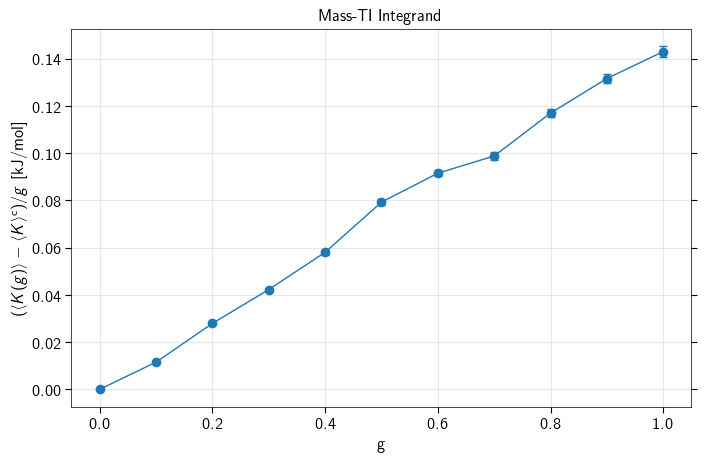

In [13]:
T = 300.0 #Kelvin
tutorialpath = Path("outputs")
path = tutorialpath.joinpath('mass_ti')
dir_list = [f"{i*0.1:.1f}" for i in range(1,11)]
du_list, sigma_list, g_list = utils.mass_TI_integrand(path, T, dir_list, skip=100)


In [14]:
T = 300.0
# Integrate and propagate error
dF_ca2qa = 2 * np.trapz(y=du_list, x=g_list)
dF_ca2qa_err =  np.sqrt( 4*np.trapz(y=sigma_list**2, x=g_list) )
# Print the free energy difference from the Mass‐TI
print("Mass TI free energy difference:")
utils.print_energy(dF_ca2qa, error=dF_ca2qa_err)
print("Mass TI total free energy:")
F_qa = F_ca + dF_ca2qa
F_qa_err = np.sqrt(dF_ch2ca_err**2 + dF_ca2qa_err**2)
utils.print_energy(F_qa, error=F_qa_err)

Mass TI free energy difference:
   0.056 ± 0.001 [mHa]
   1.51 ± 0.03 [meV]
   0.146 ± 0.003 [kJ/mol]

Mass TI total free energy:
   0.179 ± 0.002 [mHa]
   4.88 ± 0.06 [meV]
   0.470 ± 0.006 [kJ/mol]



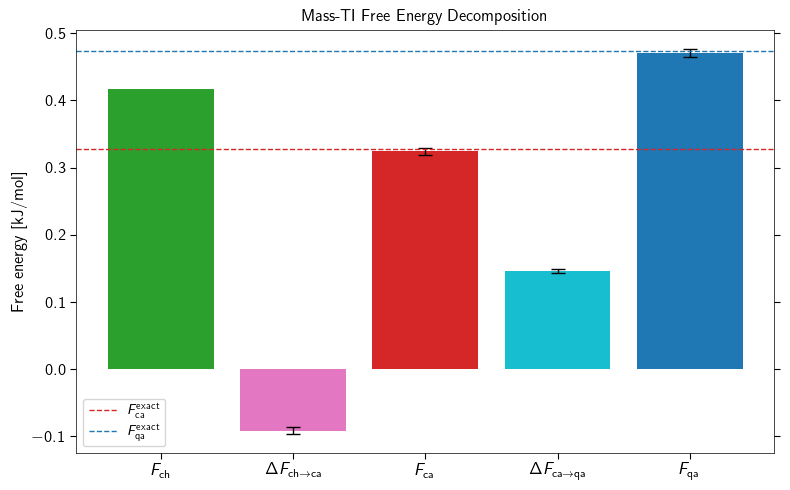

In [15]:
utils.plot_MassTI_free_energy_decomposition(
    F_ch, 
    dF_ch2ca, dF_ch2ca_err, 
    dF_ca2qa, dF_ca2qa_err,  
    1.249e-4, 1.806e-4)

### PIMD TI

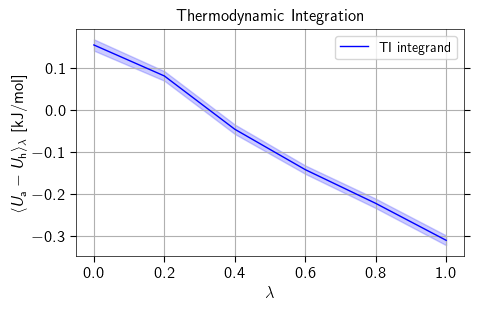

In [16]:
#Compute PIMD-TI integrand
l_list = np.arange(0,11,2)/10
dir_list = [f"{l:.1f}" for l in l_list]
base_path = Path("outputs").joinpath('pimd_ti') 
filename = 'simulation.pots'
du_list, duerr_list = utils.TI_integrand(dir_list, base_path, filename, skip=100)

In [17]:
# Integrate the energy difference using trapezoidal rule
dF_qh2qa = np.trapz(x=l_list, y=du_list)
# The corresponding error can be computed as
dF_qh2qa_err = np.sqrt(np.trapz(x=l_list, y=duerr_list**2))
# Compute the quantum anharmonic free energy by adding the free energy difference to the harmonic free energy
T = 300.0 # Kelvin
F_qh = quantum_harmonic_free_energy(Ws[-1], T)
print("Quantum harmonic free energy:")
utils.print_energy(F_qh)
print("Anharmonic correction:")
utils.print_energy(dF_qh2qa, error=dF_qh2qa_err)
print("Quantum free energy:")
F_qa = F_qh + dF_qh2qa
utils.print_energy(F_qa, error=dF_qh2qa_err)

Quantum harmonic free energy:
   0.213 [mHa]
   5.80 [meV]
   0.560 [kJ/mol]

Anharmonic correction:
   -0.031 ± 0.004 [mHa]
   -0.85 ± 0.12 [meV]
   -0.082 ± 0.011 [kJ/mol]

Quantum free energy:
   0.182 ± 0.004 [mHa]
   4.95 ± 0.12 [meV]
   0.478 ± 0.011 [kJ/mol]



## Final Result

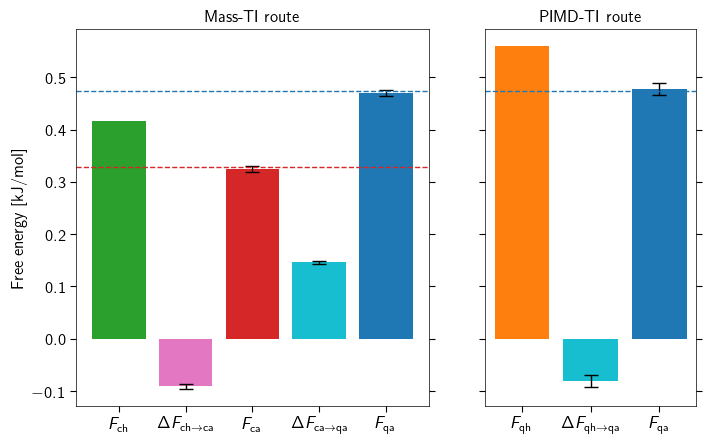

In [18]:
utils.plot_free_energy_decomposition(
    F_ch, 
    dF_ch2ca, dF_ch2ca_err, 
    dF_ca2qa, dF_ca2qa_err, 
    F_qh, 
    dF_qh2qa, dF_qh2qa_err, 
    1.249e-4, 1.806e-4)